# K-POP 아이돌 데이터로 산포도 그리기

먼저 지난번과 같이 CSV 파일을 불러온 뒤, 아이돌의 `Height`와 `Weight` 관계를 산포도로 그려 봅니다.  
이후 새로운 그룹인 코르티스 정보를 직접 추가하고, 그래프에서 추가된 데이터가 어떻게 나타나는지 확인합니다.

In [1]:
# CSV 파일 불러오기

from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt

uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

df.head()

Saving kpopidolsv3.csv to kpopidolsv3.csv


,Stage Name,Full Name,Korean Name,K Stage Name,Date of Birth,Group,Debut,Company,Country,Second Country,Height,Weight,Birthplace,Other Group,Former Group,Gender
0,2Soul,Kim Younghoon,김영훈,이솔,10/09/1997,7 O'clock,26/08/2014,Jungle,South Korea,NaN,172.0,55.0,NaN,NaN,NaN,M
1,A.M,Seong Hyunwoo,성현우,에이엠,31/12/1996,Limitless,9/07/2019,ONO,South Korea,NaN,181.0,62.0,NaN,NaN,NaN,M
2,Ace,Jang Wooyoung,장우영,에이스,28/08/1992,VAV,31/10/2015,A team,South Korea,NaN,177.0,63.0,NaN,NaN,NaN,M
3,Aeji,Kwon Aeji,권애지,애지,25/10/1999,Hash Tag,11/10/2017,LUK,South Korea,NaN,163.0,NaN,Daegu,NaN,NaN,F
4,AhIn,Lee Ahin,이아인,아인,27/09/1999,MOMOLAND,9/11/2016,Double Kick,South Korea,NaN,160.0,44.0,Wonju,NaN,NaN,F


## Height와 Weight 관계 살펴보기

산포도는 두 숫자 데이터 사이의 관계를 점으로 표현하는 그래프입니다.  
여기서는 키(`Height`)가 커질수록 몸무게(`Weight`)가 어떻게 변하는지 확인해 보겠습니다.

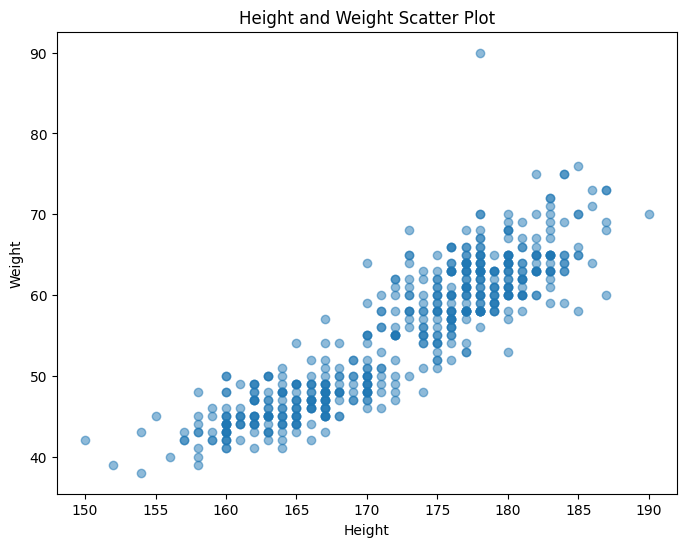

In [2]:
# 지난 시간 복습: Height, Weight 관계 산포도 그래프 그리기

plt.figure(figsize=(8, 6))
plt.scatter(df["Height"], df["Weight"], alpha=0.5)

plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("Height and Weight Scatter Plot")

plt.show()

## 코르티스 정보 추가하기

이제 데이터프레임에 새로운 아이돌 정보를 추가해 보겠습니다.  
아래 예시는 코르티스 멤버 정보를 실습용 데이터로 추가하는 코드입니다.

In [3]:
# 코르티스 정보 추가하기 실습

cortis_data = pd.DataFrame([
    {
        "Stage Name": "James",
        "Full Name": "James",
        "Korean Name": "제임스",
        "K Stage Name": "제임스",
        "Date of Birth": "2005-10-14",
        "Group": "CORTIS",
        "Debut": 2025,
        "Company": "BIGHIT MUSIC",
        "Country": "South Korea",
        "Second Country": "",
        "Height": 180,
        "Weight": 65,
        "Birthplace": "",
        "Other Group": "",
        "Former Group": "",
        "Gender": "M"
    },
    {
        "Stage Name": "Martin",
        "Full Name": "Martin",
        "Korean Name": "마틴",
        "K Stage Name": "마틴",
        "Date of Birth": "2008-03-20",
        "Group": "CORTIS",
        "Debut": 2025,
        "Company": "BIGHIT MUSIC",
        "Country": "South Korea",
        "Second Country": "",
        "Height": 175,
        "Weight": 60,
        "Birthplace": "",
        "Other Group": "",
        "Former Group": "",
        "Gender": "M"
    }
])

df_new = pd.concat([df, cortis_data], ignore_index=True)

df_new.tail()

,Stage Name,Full Name,Korean Name,K Stage Name,Date of Birth,Group,Debut,Company,Country,Second Country,Height,Weight,Birthplace,Other Group,Former Group,Gender
1775,Zuho,Bae Juho,백주호,주호,4/07/1996,SF9,5/10/2016,FNC,South Korea,NaN,NaN,NaN,NaN,NaN,NaN,M
1776,Z-UK,Jeong Jaewook,정재욱,지욱,27/01/1993,NaN,NaN,NaN,South Korea,NaN,174.0,62.0,NaN,NaN,Bigflo,M
1777,Zuny,Kim Joomi,김주미,주니,8/12/1994,Ladies' Code,7/03/2013,Polaris,South Korea,NaN,NaN,NaN,Gwangju,NaN,NaN,F
1778,James,James,제임스,제임스,2005-10-14,CORTIS,2025,BIGHIT MUSIC,South Korea,,180.0,65.0,,,,M
1779,Martin,Martin,마틴,마틴,2008-03-20,CORTIS,2025,BIGHIT MUSIC,South Korea,,175.0,60.0,,,,M


## 코르티스 정보를 추가한 뒤 산포도 다시 그리기

새로운 데이터가 추가되었으므로, 같은 방식으로 산포도를 다시 그려 보겠습니다.  
그래프의 점 개수가 이전보다 늘어난 것을 확인할 수 있습니다.

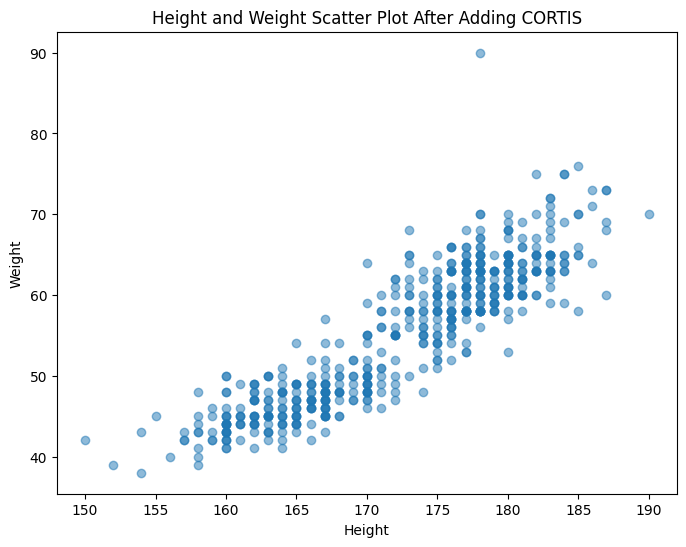

In [4]:
# 산포도 다시 그리기

plt.figure(figsize=(8, 6))
plt.scatter(df_new["Height"], df_new["Weight"], alpha=0.5)

plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("Height and Weight Scatter Plot After Adding CORTIS")

plt.show()

## 산포도에서 추가한 코르티스 정보 확인하기

마지막으로 기존 데이터는 회색 점으로, 코르티스 데이터는 더 크게 표시하여 그래프에서 쉽게 찾을 수 있도록 해 보겠습니다.

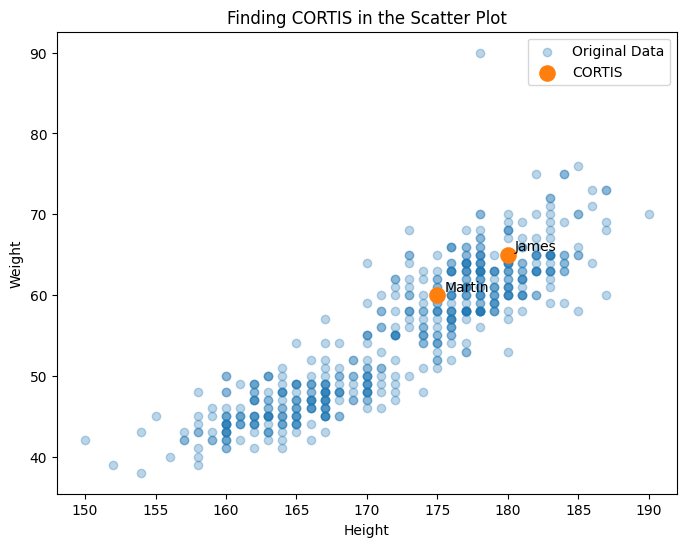

In [5]:
# 산포도에서 추가한 코르티스 정보 확인하기

cortis = df_new[df_new["Group"] == "CORTIS"]

plt.figure(figsize=(8, 6))

plt.scatter(df["Height"], df["Weight"], alpha=0.3, label="Original Data")
plt.scatter(cortis["Height"], cortis["Weight"], s=120, label="CORTIS")

for i, row in cortis.iterrows():
    plt.text(row["Height"] + 0.5, row["Weight"] + 0.5, row["Stage Name"])

plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("Finding CORTIS in the Scatter Plot")
plt.legend()

plt.show()

# Ⅲ. 데이터와 기계학습
## 2. 기계학습 모델
### 3-2-1 분류 모델 (속성과 유형: KNN & 로지스틱 회귀)

---
* **학습 목표**
  1. 분류 모델의 개념을 이해하고, $k$-최근접 이웃($k$-NN)과 로지스틱 회귀의 작동 원리를 설명할 수 있다.
  2. 데이터의 속성과 유형에 따라 적절한 분류 모델을 선택할 수 있다.
  3. 구글 코랩(Google Colab) 환경에서 두 모델을 구현하고 시각화하여 성능을 대조할 수 있다.

* **핵심 요소**
  * 분류 모델(Classification Model)
  * $k$-최근접 이웃($k$-NN, $k$-Nearest Neighbors)
  * 로지스틱 회귀(Logistic Regression)
  * 결정 경계(Decision Boundary)

## 1. 분류 모델의 개요

### **(1) 분류 모델이란 무엇일까?**
* **정의**: 기계학습의 지도학습(Supervised Learning) 중 하나로, 입력된 데이터의 속성(Feature)들을 분석하여 미리 정의된 몇 개의 범주(Class/Label) 중 하나로 예측하여 출력하는 모델입니다.
* **출력값의 형태**: 연속적인 수치(예: 온도, 가격)를 예측하는 회귀 모델과 달리, 분류 모델은 '스팸/정상', '붓꽃의 품종(Setosa/Versicolor/Virginica)'과 같이 불연속적인 이산형 변수(범주형 데이터)를 출력합니다.

### **(2) 주요 분류 알고리즘**
1. **$k$-최근접 이웃 ($k$-NN)**: 데이터 간의 거리를 측정하여 가장 가까운 이웃들의 선택을 따르는 직관적인 알고리즘입니다.
2. **로지스틱 회귀 (Logistic Regression)**: 데이터가 특정 범주에 속할 확률을 0과 1 사이의 S자 곡선(시그모이드 함수)으로 계산하여 분류하는 알고리즘입니다.

## 2. $k$-최근접 이웃 ($k$-NN) 알고리즘의 원리

### **(1) 작동 메커니즘**
* "유리창을 통해 비치는 주변 풍경과 유사한 성질을 갖는다"는 유추에서 출발합니다.
* 새로운 데이터가 주어졌을 때, 기존 데이터 공간에서 가장 가까운 거리(대개 유클리드 거리)에 있는 $k$개의 데이터를 찾습니다.
* 찾은 이웃 데이터 중 가장 다수를 차지하는 범주(다수결의 원칙)로 새로운 데이터의 범주를 결정합니다.



### **(2) 하이퍼파라미터 $k$의 영향**
* **$k$가 너무 작을 때 ($k=1$)**: 모델이 매우 민감해져 학습 데이터의 노이즈나 이상치(Outlier)까지 학습하게 되며, 과대적합(Overfitting)이 발생할 수 있습니다.
* **$k$가 너무 클 때**: 주변의 넓은 범위 데이터를 모두 포함하므로 분류 경계가 지나치게 뭉툭해져 세밀한 패턴을 놓치는 과소적합(Underfitting)이 발생할 수 있습니다.

## 3. 로지스틱 회귀 (Logistic Regression) 알고리즘의 원리

### **(1) 작동 메커니즘**
* 이름은 '회귀'이지만 선형 회귀 분석의 출력을 범주형 데이터를 처리할 수 있도록 확장한 **분류 알고리즘**입니다.
* 선형 회귀의 선형 결합 수식 $z = w_1x_1 + w_2x_2 + ... + b$의 결과값은 $-\infty$부터 $+\infty$까지의 범위를 가집니다. 이를 확률값으로 변환하기 위해 시그모이드 함수(Sigmoid Function)에 입력합니다.

### **(2) 시그모이드 함수 공식**
$$y = \frac{1}{1 + e^{-z}}$$

* 이 함수의 출력값 $y$는 항상 $0 \le y \le 1$의 범위를 가지며, 특정 클래스에 속할 **확률**을 나타냅니다.
* 기본적으로 출력 확률이 0.5(기준치) 이상이면 양성 클래스(1), 0.5 미만이면 음성 클래스(0)로 분류 기준을 수립합니다.

In [ ]:
import sys
import os
import subprocess
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

def set_korean_font():
    is_colab = "google.colab" in sys.modules

    if is_colab:
        font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

        if not os.path.exists(font_path):
            subprocess.run(["apt-get", "update", "-qq"], check=False)
            subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], check=False)
            subprocess.run(["fc-cache", "-fv"], check=False)

        fm.fontManager.addfont(font_path)
        plt.rcParams["font.family"] = "NanumGothic"

    elif sys.platform == "darwin":
        plt.rcParams["font.family"] = "AppleGothic"

    elif sys.platform.startswith("win"):
        plt.rcParams["font.family"] = "Malgun Gothic"

    else:
        plt.rcParams["font.family"] = "NanumGothic"

    plt.rcParams["axes.unicode_minus"] = False

set_korean_font()
print("구글 코랩 환경 한글 폰트 적용 완료.")

구글 코랩 환경 한글 폰트 적용 완료.


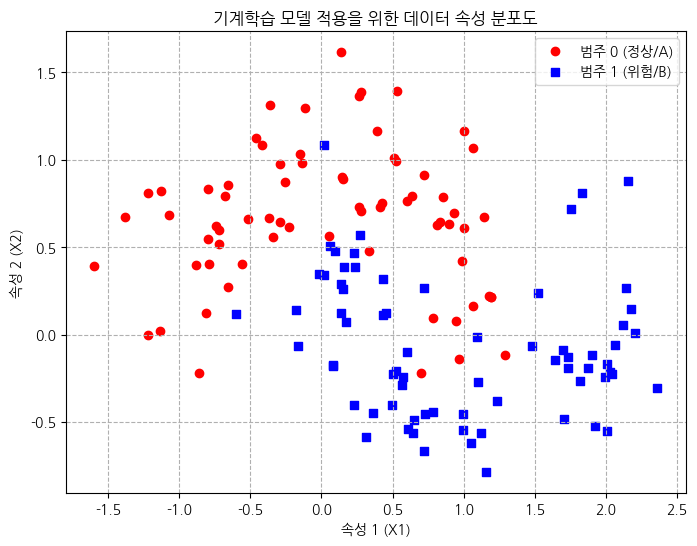

In [ ]:
# [실습] KNN과 로지스틱 회귀 분석을 위한 가상 데이터 세트 생성
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# 두 개의 데이터 속성(Feature)을 가진 2차원 분류용 반달 데이터 세트 생성
X, y = make_moons(n_samples=200, noise=0.25, random_state=42)

# 학습 데이터와 테스트 데이터 분리 (비율 7:3)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 생성된 데이터 시각화
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='red', marker='o', label='범주 0 (정상/A)')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='blue', marker='s', label='범주 1 (위험/B)')
plt.title("기계학습 모델 적용을 위한 데이터 속성 분포도")
plt.xlabel("속성 1 (X1)")
plt.ylabel("속성 2 (X2)")
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

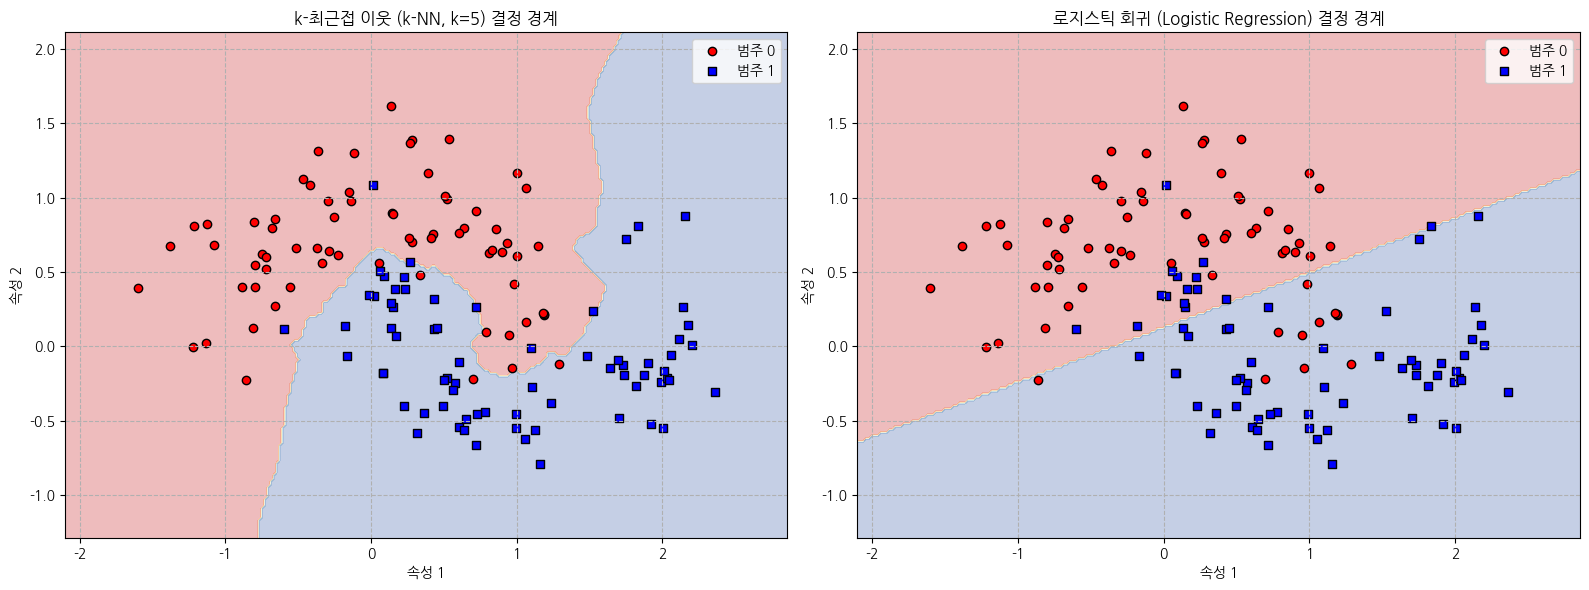

In [ ]:
# [실습] 두 모델의 학습 및 결정 경계(Decision Boundary) 비교 시각화
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# 1. 모델 정의 및 학습
knn_model = KNeighborsClassifier(n_neighbors=5)
lr_model = LogisticRegression()

knn_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)

# 2. 결정 경계를 그리기 위한 격자 포인트 플로팅 함수 정의
def plot_decision_boundaries(X, y, model, title, ax):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], color='red', marker='o', edgecolor='k', label='범주 0')
    ax.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', marker='s', edgecolor='k', label='범주 1')
    ax.set_title(title)
    ax.set_xlabel("속성 1")
    ax.set_ylabel("속성 2")
    ax.legend()
    ax.grid(True, linestyle='--')

# 3. 서브플롯을 이용한 두 모델 대조 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

plot_decision_boundaries(X_train, y_train, knn_model, "k-최근접 이웃 (k-NN, k=5) 결정 경계", ax1)
plot_decision_boundaries(X_train, y_train, lr_model, "로지스틱 회귀 (Logistic Regression) 결정 경계", ax2)

plt.tight_layout()
plt.show()

=== [k-NN 성능 요약 데이터] ===
혼동 행렬(Confusion Matrix):
[[28  2]
 [ 1 29]]
정확도 (Accuracy) : 0.9500
정밀도 (Precision): 0.9355
재현율 (Recall)   : 0.9667

=== [로지스틱 회귀 성능 요약 데이터] ===
혼동 행렬(Confusion Matrix):
[[26  4]
 [ 3 27]]
정확도 (Accuracy) : 0.8833
정밀도 (Precision): 0.8710
재현율 (Recall)   : 0.9000



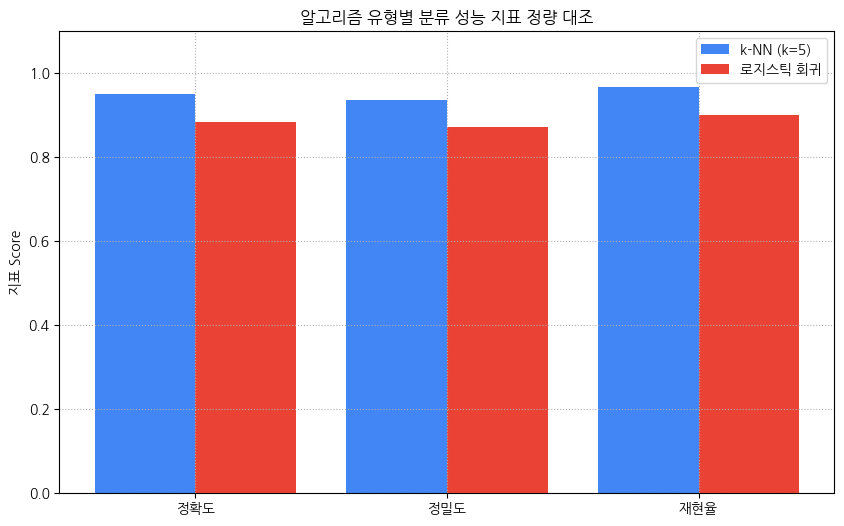

In [ ]:
# [실습] 혼동 행렬(Confusion Matrix)과 분류 평가지표 연산 및 대조
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def evaluate_model_performance(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    print(f"=== [{model_name} 성능 요약 데이터] ===")
    print(f"혼동 행렬(Confusion Matrix):\n{cm}")
    print(f"정확도 (Accuracy) : {acc:.4f}")
    print(f"정밀도 (Precision): {prec:.4f}")
    print(f"재현율 (Recall)   : {rec:.4f}\n")
    return [acc, prec, rec]

knn_scores = evaluate_model_performance(knn_model, X_test, y_test, "k-NN")
lr_scores = evaluate_model_performance(lr_model, X_test, y_test, "로지스틱 회귀")

# 두 모델 지표 성능 대조 막대그래프 출력
metrics_list = ['정확도', '정밀도', '재현율']
x_axis = np.arange(len(metrics_list))

plt.figure(figsize=(10, 6))
plt.bar(x_axis - 0.2, knn_scores, width=0.4, label='k-NN (k=5)', color='#4285F4')
plt.bar(x_axis + 0.2, lr_scores, width=0.4, label='로지스틱 회귀', color='#EA4335')

plt.xticks(x_axis, metrics_list)
plt.ylim(0, 1.1)
plt.title("알고리즘 유형별 분류 성능 지표 정량 대조")
plt.ylabel("지표 Score")
plt.legend()
plt.grid(True, linestyle=':')
plt.show()

## 4. 데이터 속성에 따른 알고리즘 특성 비교 정리

교재 내용 및 실습 결과를 바탕으로 두 모델의 속성 처리 방식을 비교 분석합니다.

| 비교 항목 | $k$-최근접 이웃 ($k$-NN) | 로지스틱 회귀 (Logistic Regression) |
| :--- | :--- | :--- |
| **모델의 형태** | 비모수적 모델 (수식적 구조 없음) | 모수적 모델 (선형 결합 및 시그모이드 수식 형태) |
| **결정 경계의 특성** | 데이터 분포의 세부 굴곡을 반영하는 복잡한 비선형 경계 형성 | 공간을 평면이나 직선으로 분할하는 직선형(선형) 경계 형성 |
| **속성 변화 영향도** | 모든 속성 간의 거리를 동등하게 취급하므로 특정 데이터 스케일에 민감함 | 각 데이터 속성에 부여되는 가중치(Weights) 크기를 통해 속성의 중요도를 파악 가능 |
| **적합한 데이터 유형** | 데이터 양이 아주 많지 않고 복잡한 패턴을 가진 정형 데이터 속성 | 선형적인 경계나 확률값 기반의 추정이 요구되는 정형 데이터 속성 |

## 실습 준비
코르티스 정보에 이어서 실습해 봅시다.

k-NN 정확도: 0.9805825242718447
로지스틱 회귀 정확도: 0.970873786407767

코르티스 예측 결과
James
k-NN 예측: M
Logistic Regression 예측: M

Martin
k-NN 예측: M
Logistic Regression 예측: M



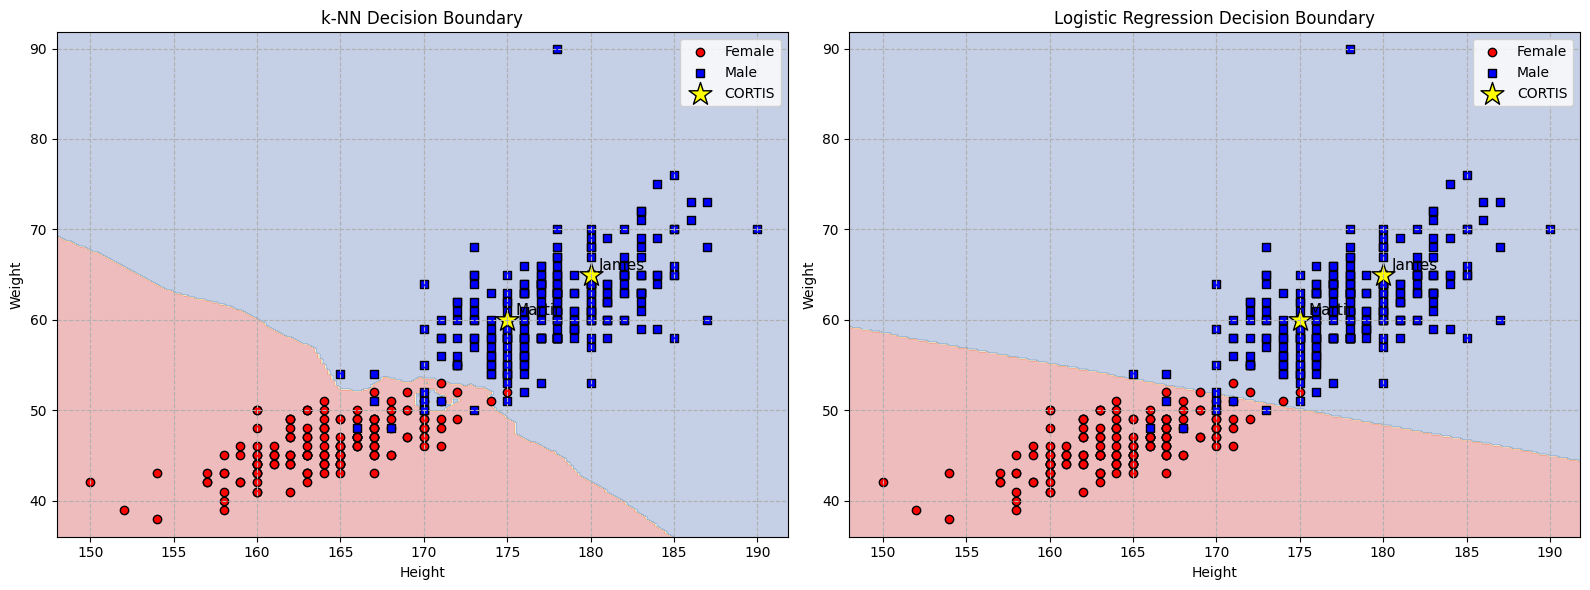

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. 사용할 데이터 선택
# df가 아니라 df_new를 사용해야 코르티스 데이터가 포함됨
data = df_new[["Stage Name", "Group", "Height", "Weight", "Gender"]].dropna()

# Gender가 F 또는 M인 데이터만 사용
data = data[data["Gender"].isin(["F", "M"])].copy()

# Gender를 숫자로 변환: F = 0, M = 1
data["Gender_Code"] = data["Gender"].map({"F": 0, "M": 1})

# 코르티스 데이터 따로 저장
cortis_data_ml = data[data["Group"] == "CORTIS"]

# 모델 학습에는 전체 데이터 사용
X = data[["Height", "Weight"]].values
y = data["Gender_Code"].values

# 2. 학습용 / 테스트용 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. 모델 정의 및 학습
knn_model = KNeighborsClassifier(n_neighbors=5)
lr_model = LogisticRegression(max_iter=1000)

knn_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)

# 4. 정확도 확인
knn_pred = knn_model.predict(X_test)
lr_pred = lr_model.predict(X_test)

print("k-NN 정확도:", accuracy_score(y_test, knn_pred))
print("로지스틱 회귀 정확도:", accuracy_score(y_test, lr_pred))

# 5. 코르티스 예측 결과 확인
X_cortis = cortis_data_ml[["Height", "Weight"]].values

cortis_knn_pred = knn_model.predict(X_cortis)
cortis_lr_pred = lr_model.predict(X_cortis)

print("\n코르티스 예측 결과")
for i, name in enumerate(cortis_data_ml["Stage Name"]):
    print(name)
    print("k-NN 예측:", "M" if cortis_knn_pred[i] == 1 else "F")
    print("Logistic Regression 예측:", "M" if cortis_lr_pred[i] == 1 else "F")
    print()

# 6. 결정 경계를 그리기 위한 함수 정의
def plot_decision_boundaries(X, y, model, title, ax, cortis_data_ml):
    x_min, x_max = X[:, 0].min() - 2, X[:, 0].max() + 2
    y_min, y_max = X[:, 1].min() - 2, X[:, 1].max() + 2

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.2),
        np.arange(y_min, y_max, 0.2)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)

    ax.scatter(
        X[y == 0, 0], X[y == 0, 1],
        color="red", marker="o", edgecolor="k",
        label="Female"
    )

    ax.scatter(
        X[y == 1, 0], X[y == 1, 1],
        color="blue", marker="s", edgecolor="k",
        label="Male"
    )

    # 코르티스 데이터 강조 표시
    ax.scatter(
        cortis_data_ml["Height"],
        cortis_data_ml["Weight"],
        color="yellow", marker="*", s=300, edgecolor="black",
        label="CORTIS"
    )

    # 코르티스 이름 표시
    for _, row in cortis_data_ml.iterrows():
        ax.text(
            row["Height"] + 0.5,
            row["Weight"] + 0.5,
            row["Stage Name"],
            fontsize=11
        )

    ax.set_title(title)
    ax.set_xlabel("Height")
    ax.set_ylabel("Weight")
    ax.legend()
    ax.grid(True, linestyle="--")

# 7. 두 모델의 결정 경계 비교 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

plot_decision_boundaries(
    X_train, y_train, knn_model,
    "k-NN Decision Boundary",
    ax1,
    cortis_data_ml
)

plot_decision_boundaries(
    X_train, y_train, lr_model,
    "Logistic Regression Decision Boundary",
    ax2,
    cortis_data_ml
)

plt.tight_layout()
plt.show()

In [8]:
# KNN, Logistic Regression 학습 및 오분류 데이터 확인

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. 사용할 데이터 선택
data = df_new[["Stage Name", "Group", "Height", "Weight", "Gender"]].dropna()
data = data[data["Gender"].isin(["F", "M"])].copy()

# Gender를 숫자로 변환: F = 0, M = 1
data["Gender_Code"] = data["Gender"].map({"F": 0, "M": 1})

# 2. 훈련 데이터와 테스트 데이터 나누기
train_df, test_df = train_test_split(
    data,
    test_size=0.2,
    random_state=42,
    stratify=data["Gender_Code"]
)

X_train = train_df[["Height", "Weight"]]
y_train = train_df["Gender_Code"]

X_test = test_df[["Height", "Weight"]]
y_test = test_df["Gender_Code"]

# 3. 모델 학습
knn_model = KNeighborsClassifier(n_neighbors=5)
lr_model = LogisticRegression(max_iter=1000)

knn_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)

# 4. 예측
knn_pred = knn_model.predict(X_test)
lr_pred = lr_model.predict(X_test)

# 5. 정확도 출력
print("k-NN 정확도:", accuracy_score(y_test, knn_pred))
print("Logistic Regression 정확도:", accuracy_score(y_test, lr_pred))

# 6. 성별 코드 변환용
gender_map = {0: "여성", 1: "남성"}

# 7. KNN 오분류 데이터 확인
knn_result = test_df.copy()
knn_result["실제 성별"] = knn_result["Gender_Code"].map(gender_map)
knn_result["예측 성별"] = pd.Series(knn_pred, index=knn_result.index).map(gender_map)

misclassified_knn = knn_result[
    knn_result["Gender_Code"] != knn_pred
]

print("\nk-NN 오분류 개수:", len(misclassified_knn))
display(
    misclassified_knn[
        ["Stage Name", "Group", "Height", "Weight", "실제 성별", "예측 성별"]
    ]
)

# 8. Logistic Regression 오분류 데이터 확인
lr_result = test_df.copy()
lr_result["실제 성별"] = lr_result["Gender_Code"].map(gender_map)
lr_result["예측 성별"] = pd.Series(lr_pred, index=lr_result.index).map(gender_map)

misclassified_lr = lr_result[
    lr_result["Gender_Code"] != lr_pred
]

print("\nLogistic Regression 오분류 개수:", len(misclassified_lr))
display(
    misclassified_lr[
        ["Stage Name", "Group", "Height", "Weight", "실제 성별", "예측 성별"]
    ]
)

k-NN 정확도: 0.9805825242718447
Logistic Regression 정확도: 0.970873786407767

k-NN 오분류 개수: 2


,Stage Name,Group,Height,Weight,실제 성별,예측 성별
1510,Vita,MAJORS,168.0,54.0,여성,남성
542,Hyosun,H.U.B,170.0,54.0,여성,남성



Logistic Regression 오분류 개수: 3


,Stage Name,Group,Height,Weight,실제 성별,예측 성별
1510,Vita,MAJORS,168.0,54.0,여성,남성
542,Hyosun,H.U.B,170.0,54.0,여성,남성
1006,Min,We In The Zone,171.0,50.0,남성,여성


## 실습 과제

1. KNN의 n_neighbors 값을 3, 7, 9로 바꾸어 보세요.
2. Height만 사용했을 때 정확도를 측정해 보세요.
3. Weight만 사용했을 때 정확도를 측정해 보세요.
4. Height=170, Weight=50인 경우 성별을 예측해 보세요.
5. Height=185, Weight=75인 경우 성별을 예측해 보세요.

어떤 모델이 더 안정적으로 예측하는지 관찰해 보세요.

# 만약 대학 면접을 본다면?

실습 기반 질문

* James가 남성으로 예측된 이유는 무엇인가요?
* Martin이 여성 아이돌들 사이에 위치했다면 결과가 달라질 수 있었을까요?
* Height만 사용하면 결과가 어떻게 달라질까요?
* Weight만 사용하면 결과가 어떻게 달라질까요?
* 새로운 아이돌의 키가 200cm라면 예측 결과를 신뢰할 수 있을까요?

⸻

그래프 해석 질문

* 산포도에서 무엇을 확인할 수 있었나요?
* 남성과 여성 데이터가 잘 구분되어 있었나요?
* 만약 두 집단이 완전히 겹쳐 있다면 어떤 문제가 발생할까요?
* 오분류된 데이터는 어떤 특징을 가지고 있었나요?

⸻

심화 질문

상위권 대학에서 나올 수 있습니다.

* 데이터가 많아지면 KNN의 단점은 무엇인가요?
* 머신러닝 모델이 항상 정답을 맞힐 수 없는 이유는 무엇인가요?
* 테스트 데이터에서도 100% 정확도가 나온다면 좋은 모델이라고 할 수 있나요?
* 데이터가 적을 때 발생할 수 있는 문제는 무엇인가요?